In [1]:
! pip install langchain langchain-openai langchain-community langgraph python-dotenv faiss-cpu pypdf

  Using cached langchain-1.2.18-py3-none-any.whl.metadata (5.8 kB)
  Using cached langchain_core-1.3.3-py3-none-any.whl.metadata (4.5 kB)
Using cached langchain-1.2.18-py3-none-any.whl (113 kB)
Using cached langchain_core-1.3.3-py3-none-any.whl (543 kB)
   ---------------------------------------- 0.0/18.9 MB ? eta -:--:--
   - -------------------------------------- 0.8/18.9 MB 4.3 MB/s eta 0:00:05
   --- ------------------------------------ 1.8/18.9 MB 4.4 MB/s eta 0:00:04
   ----- ---------------------------------- 2.6/18.9 MB 4.1 MB/s eta 0:00:05
   ----- ---------------------------------- 2.6/18.9 MB 4.1 MB/s eta 0:00:05
   ------- -------------------------------- 3.7/18.9 MB 3.4 MB/s eta 0:00:05
   --------- ------------------------------ 4.5/18.9 MB 3.5 MB/s eta 0:00:05
   ----------- ---------------------------- 5.5/18.9 MB 3.6 MB/s eta 0:00:04
   ------------- -------------------------- 6.3/18.9 MB 3.6 MB/s eta 0:00:04
   -------------- ------------------------- 7.1/18.9 MB 3.6 

In [3]:
!pip install -qU langchain-text-splitters

In [4]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition

c:\Users\Sanjog Bhalla\Desktop\Langgraph - CampusX\.venv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [5]:
load_dotenv()

True

In [6]:
llm = ChatOpenAI(model='gpt-4o-mini')

In [ ]:
# load the PDF document
loader = PyPDFLoader('intro-to-ml.pdf')
docs = loader.load()

In [8]:
docs[0]

Document(metadata={'producer': '3-Heights(TM) PDF Optimization Shell 5.9.1.5 (http://www.pdf-tools.com)', 'creator': 'AH CSS Formatter V6.2 MR4 for Linux64 : 6.2.6.18551 (2014/09/24 15:00JST)', 'creationdate': '2016-09-21T13:04:39+00:00', 'author': 'Andreas C. Müller and Sarah Guido', 'title': 'Introduction to Machine Learning with Python', 'trapped': '/False', 'moddate': '2020-08-19T07:09:16+02:00', 'source': 'intro-to-ml.pdf', 'total_pages': 392, 'page': 0, 'page_label': 'Cover'}, page_content='Andreas C. Müller & Sarah Guido\nIntroduction to \nMachine \nLearning  \nwith P y t h o n   \nA GUIDE FOR DATA SCIENTISTS')

In [9]:
len(docs)

392

In [10]:
# After loading the document we will do splitting and divide our document into chunks
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs) 

In [12]:
chunks[1]

Document(metadata={'producer': '3-Heights(TM) PDF Optimization Shell 5.9.1.5 (http://www.pdf-tools.com)', 'creator': 'AH CSS Formatter V6.2 MR4 for Linux64 : 6.2.6.18551 (2014/09/24 15:00JST)', 'creationdate': '2016-09-21T13:04:39+00:00', 'author': 'Andreas C. Müller and Sarah Guido', 'title': 'Introduction to Machine Learning with Python', 'trapped': '/False', 'moddate': '2020-08-19T07:09:16+02:00', 'source': 'intro-to-ml.pdf', 'total_pages': 392, 'page': 2, 'page_label': 'i'}, page_content='Andreas C. Müller and Sarah Guido\nIntroduction to Machine Learning\nwith Python\nA Guide for Data Scientists\nBoston Farnham Sebastopol TokyoBeijing Boston Farnham Sebastopol TokyoBeijing')

In [13]:
len(chunks)

973

In [14]:
# Now we do the embedding here
embeddings = OpenAIEmbeddings(model='text-embedding-3-small')
vector_store = FAISS.from_documents(chunks, embeddings)

In [15]:
vector_store

In [ ]:
# now we make the retriever 
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k': 4}) 

In [20]:
retriever.invoke("What is a Decision Tree?")[0].page_content

'Figure 2-24. Decision boundary of tree with depth 1 (left) and corresponding tree (right)\nFigure 2-25. Decision boundary of tree with depth 2 (left) and corresponding decision\ntree (right)\nThis recursive process yields a binary tree of decisions, with each node containing a\ntest. Alternatively, you can think of each test as splitting the part of the data that is\ncurrently being considered along one axis. This yields a view of the algorithm as\nbuilding a hierarchical partition. As each test concerns only a single feature, the\nregions in the resulting partition always have axis-parallel boundaries.\nThe recursive partitioning of the data is repeated until each region in the partition\n(each leaf in the decision tree) only contains a single target value (a single class or a\nsingle regression value). A leaf of the tree that contains data points that all share the\nsame target value is called pure. The final partitioning for this dataset is shown in\nFigure 2-26.'

In [21]:
# Now we make the tool using this RAG system

@tool
def rag_tool(query):
    
    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """
    result = retriever.invoke(query)
    
    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]
    
    return {
        'query': query,
        'context': context,
        'metadata': metadata
    }

In [22]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [23]:
# Now we make the State of the Graph

class ChatState(TypedDict):
    
    messages: Annotated[list[BaseMessage], add_messages]

In [24]:
# Now we make the graph node

def chat_node(state: ChatState):
    
    messages = state['messages']
    
    response = llm_with_tools.invoke(messages)
    
    return {'messages': [response]}

In [25]:
# Now we make the tool node

tool_node = ToolNode(tools)

In [26]:
# graph structure

graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

In [27]:
graph.add_edge(START, "chat_node")

# If the LLM asked for a tool, go to ToolNode; else finish
graph.add_conditional_edges("chat_node", tools_condition)

# we will loop back to chat_node after tool execution to allow multiple tool calls in a conversation
graph.add_edge("tools", "chat_node")

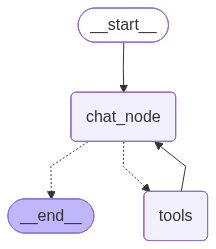

In [28]:
chatbot = graph.compile()

chatbot

In [29]:
result = chatbot.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "Using the pdf notes, explain how to find the ideal value of K in KNN"
                )
            )
        ]
    }
)

In [30]:
print(result['messages'][-1].content)

To find the ideal value of \( K \) in the K-Nearest Neighbors (KNN) algorithm, here are some key considerations and approaches:

1. **Understanding the Influence of \( K \)**:
   - A smaller value of \( K \) (like 1) can lead to very sensitive predictions that closely follow the training data, which may result in overfitting. This means the model performs well on the training set but poorly on unseen data.
   - A larger \( K \) results in smoother and more generalized predictions, as it considers more neighbors when making decisions. However, too large a \( K \) can lead to underfitting, where the model fails to capture the underlying patterns of the data.

2. **Common Practice**:
   - It is often recommended to start experimenting with small values of \( K \), typically 3 or 5, as they tend to perform reasonably well. The performance can then be adjusted depending on the results obtained.

3. **Cross-Validation**:
   - One effective method to determine the ideal \( K \) is to use cros